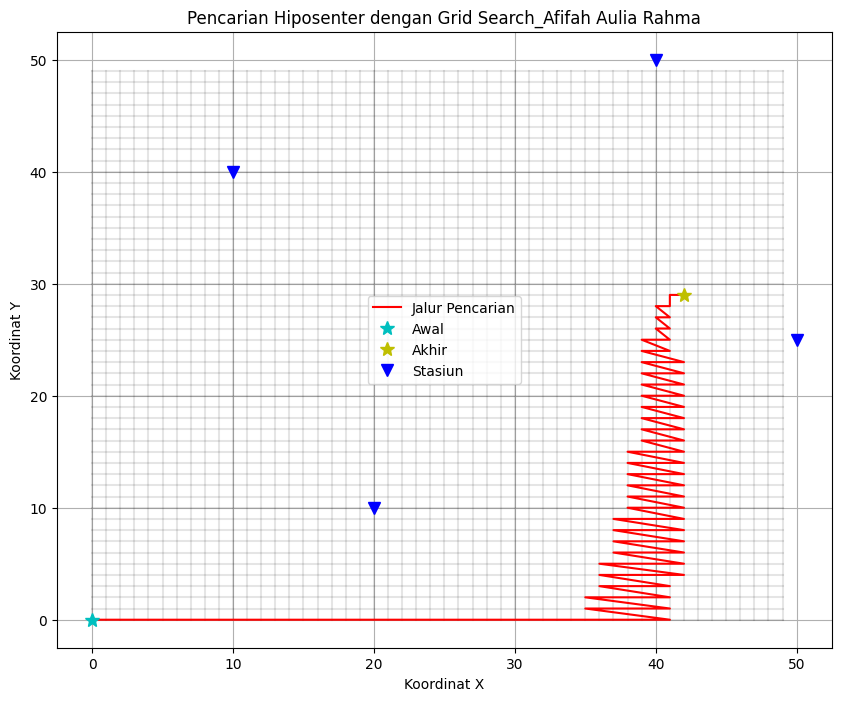

Koordinat X Hiposenter : 42
Koordinat Y Hiposenter : 29
Nilai Misfit Minimum   : 0.3892487158369358
Jumlah Iterasi: 176


In [1]:
import numpy as np                              #import library numpy untuk operasi matematis
import matplotlib.pyplot as plt                 #import library matplotlib untuk memvisualisasikan grafik

Vavg = 4                                        #Velocity rata-rata gelombang seismik
tobs = [7.1, 1.8, 5.0, 7.9]                    #Waktu observasi pada tiap stasiun

Ksts = [20, 50, 40, 10]                        #Koordinat X stasiun
Ysts = [10, 25, 50, 40]                        #Koordinat Y stasiun

# Grid
L = 1                                           #Interval grid pencarian
X0 = np.arange(0, 50, L)                       #Membuat grid koordinat X dari 0–49
Y0 = np.arange(0, 50, L)                       #Membuat grid koordinat Y dari 0–49

# Grid search
P = 10                                          #Nilai awal misfit minimum
HypoX = []                                      #List untuk menyimpan koordinat X hiposenter
HypoY = []                                      #List untuk menyimpan koordinat Y hiposenter

for i in range(len(Y0)):                        #Perulangan untuk seluruh grid Y
    for j in range(len(X0)):                    #Perulangan untuk seluruh grid X
        Dt = []                                 #List untuk menyimpan selisih waktu kuadrat
        for k in range(len(Ksts)):              #Perulangan untuk setiap stasiun
            tcal = np.sqrt((X0[j]-Ksts[k])**2 + (Y0[i]-Ysts[k])**2) / Vavg #Menghitung waktu tempuh teoritis berdasarkan jarak dan velocity 
            Dt.append((tobs[k] - tcal)**2)      #Menghitung selisih kuadrat antara waktu observasi dan waktu teoritis
                                                 

        misfit = np.sqrt(np.mean(Dt))           #Menghitung RMS misfit
        
        if misfit < P:                          #Seleksi jika misfit lebih kecil
            HypoX.append(X0[j])                 #Menyimpan koordinat X terbaik
            HypoY.append(Y0[i])                 #Menyimpan koordinat Y terbaik
            P = misfit                          #Update nilai misfit minimum

# Plot
plt.figure(figsize=(10, 8))                    #Membuat ukuran figure grafik

# Grid
for x in X0:                                    #Perulangan membuat garis grid vertikal
    plt.plot([x, x], [Y0[0], Y0[-1]], 'k-', alpha=0.1)#Plot garis vertikal grid                          

for y in Y0:                                    #Perulangan membuat garis grid horizontal
    plt.plot([X0[0], X0[-1]], [y, y], 'k-', alpha=0.1) #Plot garis horizontal grid
                                                 
# Jalur pencarian
plt.plot(HypoX, HypoY, '-r', label='Jalur Pencarian')                   #Menampilkan jalur pencarian hiposenter
plt.plot(HypoX[0], HypoY[0], '*c', markersize=10, label='Awal')         #Menampilkan titik awal pencarian                                               
plt.plot(HypoX[-1], HypoY[-1], '*y', markersize=10, label='Akhir')      #Menampilkan titik akhir pencarian
                                                 
# Stasiun
plt.plot(Ksts, Ysts, 'v', markersize=8, color='blue', label='Stasiun')  #Menampilkan posisi stasiun pengamatan                 

# Label
plt.xlabel('Koordinat X')                       #Label sumbu X
plt.ylabel('Koordinat Y')                       #Label sumbu Y
plt.title('Pencarian Hiposenter dengan Grid Search_Afifah Aulia Rahma')#Judul grafik
plt.legend()                                    #Menampilkan legenda
plt.grid(True)                                  #Menampilkan grid utama
plt.show()                                      #Menampilkan grafik

# Output
print('Koordinat X Hiposenter :', HypoX[-1])    #Menampilkan koordinat X hiposenter
print('Koordinat Y Hiposenter :', HypoY[-1])    #Menampilkan koordinat Y hiposenter
print('Nilai Misfit Minimum   :', P)            #Menampilkan nilai misfit minimum
print('Jumlah Iterasi:', len(HypoX))            #Menampilkan jumlah iterasi yang dilakukan dalam pencarian hiposenter

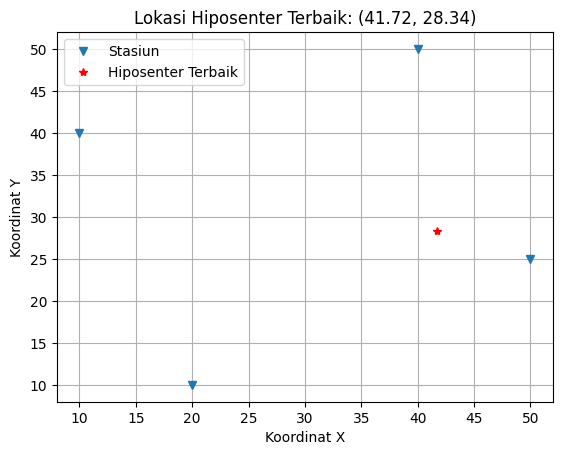

Lokasi Hiposenter Terbaik: (41.72, 28.34)
Misfit Terbaik: 0.41


In [4]:
# Monte Carlo
import numpy as np                              # Import library numpy untuk operasi matematis
import matplotlib.pyplot as plt                 # Import library matplotlib untuk visualisasi grafik
from numpy.linalg import inv                    # Import fungsi invers matriks dari numpy.linalg

Vavg = 4                                        # Kecepatan rata-rata gelombang seismik
tobs = [7.1,1.8,5.0,7.9]                       # Data waktu observasi pada tiap stasiun

#tobs = np.reshape(tobs,(len(tobs),1))         # Mengubah array menjadi matriks kolom (tidak digunakan)

Ksts = [20,50,40,10]                           # Koordinat X stasiun
Ysts = [10,25,50,40]                           # Koordinat Y stasiun

# Tebakan awal
xo_initial = 12                                # Koordinat X awal hiposenter
yo_initial = 10                                # Koordinat Y awal hiposenter

# Fungsi untuk menghitung waktu kalkulasi (tcal)
def calculate_tcal(xo, yo, xsts, ysts, vavg):
    return np.sqrt((xsts - xo)**2 + (ysts - yo)**2) / vavg  # Menghitung waktu tempuh teoritis

# Fungsi untuk menghitung error (misfit)
def calculate_misfit(tobs, tcal):
    tobs = np.array(tobs)                      # Mengubah data observasi menjadi array numpy
    tcal = np.array(tcal)                      # Mengubah data kalkulasi menjadi array numpy
    
    return np.sqrt(np.mean((tobs - tcal)**2)) # Menghitung RMS misfit

# Inisialisasi variabel
best_xo = xo_initial                           # Menyimpan koordinat X terbaik sementara
best_yo = yo_initial                           # Menyimpan koordinat Y terbaik sementara
best_misfit = float('inf')                    # Nilai awal misfit terbaik = tak hingga
n_iterations = 666                             # Jumlah iterasi Monte Carlo

# Lakukan pencarian acak (Monte Carlo)
for _ in range(n_iterations):                  # Perulangan Monte Carlo
    xo_random = np.random.uniform(0, 50)      # Membuat koordinat X acak
    yo_random = np.random.uniform(0, 50)      # Membuat koordinat Y acak

    tcal_random = [calculate_tcal(xo_random, yo_random, xsts, ysts, Vavg) for xsts, ysts in zip(Ksts, Ysts)]  # Menghitung waktu teoritis

    misfit_random = calculate_misfit(tobs, tcal_random)  # Menghitung misfit model acak

    if misfit_random < best_misfit:            # Seleksi model dengan misfit terkecil
        best_xo = xo_random                    # Update koordinat X terbaik
        best_yo = yo_random                    # Update koordinat Y terbaik
        best_misfit = misfit_random            # Update nilai misfit terbaik

# Plot hasil akhir
plt.plot(Ksts, Ysts, 'v', label='Stasiun')     # Menampilkan posisi stasiun
plt.plot(best_xo, best_yo, '*r', label='Hiposenter Terbaik')  # Menampilkan hiposenter terbaik
plt.xlabel('Koordinat X')                      # Label sumbu X
plt.ylabel('Koordinat Y')                      # Label sumbu Y
plt.legend()                                   # Menampilkan legenda
plt.title(f'Lokasi Hiposenter Terbaik: ({best_xo:.2f}, {best_yo:.2f})')  # Judul grafik
plt.grid(True)                                 # Menampilkan grid
plt.show()                                     # Menampilkan grafik

print(f"Lokasi Hiposenter Terbaik: ({best_xo:.2f}, {best_yo:.2f})")  # Output koordinat terbaik
print(f"Misfit Terbaik: {best_misfit:.2f}")    # Output nilai misfit terbaik